# Running the model

In [ ]:
!pip install torch torchvision matplotlib -q
print('✅ Done')

✅ Done


In [ ]:
import os

# Unzip using system command instead of Python's zipfile
os.makedirs('/content/makeup_images_new', exist_ok=True)
!unzip -o '/content/makeup_images (5).zip' -d '/content/makeup_images_new'

# Check contents
for cat in sorted(os.listdir('/content/makeup_images_new')):
    path = os.path.join('/content/makeup_images_new', cat)
    if os.path.isdir(path):
        count = len(os.listdir(path))
        print(f'  📁 {cat}: {count} images')

Archive:  /content/makeup_images (5).zip
   creating: /content/makeup_images_new/clean_makeup/
   creating: /content/makeup_images_new/festival_makeup/
   creating: /content/makeup_images_new/glam_makeup/
   creating: /content/makeup_images_new/no_makeup/
  inflating: /content/makeup_images_new/clean_makeup/image_339.jpg  
  inflating: /content/makeup_images_new/clean_makeup/image_289.jpg  
  inflating: /content/makeup_images_new/clean_makeup/image_192.jpg  
  inflating: /content/makeup_images_new/clean_makeup/image_120.jpg  
  inflating: /content/makeup_images_new/clean_makeup/image_072.jpg  
  inflating: /content/makeup_images_new/clean_makeup/image_384.jpg  
  inflating: /content/makeup_images_new/clean_makeup/image_127.jpg  
  inflating: /content/makeup_images_new/clean_makeup/image_054.jpg  
  inflating: /content/makeup_images_new/clean_makeup/image_332.jpg  
  inflating: /content/makeup_images_new/clean_makeup/image_226.jpg  
  inflating: /content/makeup_images_new/clean_makeup/i

🖥️  Using device: cuda
📁 Classes found: ['clean_makeup', 'festival_makeup', 'glam_makeup', 'no_makeup']
📊 Total images:  1870
🏋️  Train: 1496 | 🧪 Val: 374
✅ Model ready (ResNet18 — layer4 + fc unfrozen)
Epoch  1/20 | Train Loss: 0.629 Acc: 74.1% | Val Loss: 0.540 Acc: 82.1% | ⏱ 34.6s
Epoch  2/20 | Train Loss: 0.304 Acc: 88.0% | Val Loss: 0.335 Acc: 88.5% | ⏱ 34.4s
Epoch  3/20 | Train Loss: 0.244 Acc: 90.8% | Val Loss: 0.368 Acc: 85.8% | ⏱ 32.9s
Epoch  4/20 | Train Loss: 0.161 Acc: 94.2% | Val Loss: 0.319 Acc: 90.1% | ⏱ 34.1s
Epoch  5/20 | Train Loss: 0.146 Acc: 94.4% | Val Loss: 0.251 Acc: 92.0% | ⏱ 32.7s
Epoch  6/20 | Train Loss: 0.107 Acc: 96.2% | Val Loss: 0.191 Acc: 93.3% | ⏱ 34.0s
Epoch  7/20 | Train Loss: 0.072 Acc: 97.4% | Val Loss: 0.167 Acc: 94.7% | ⏱ 33.0s
Epoch  8/20 | Train Loss: 0.077 Acc: 97.5% | Val Loss: 0.145 Acc: 95.5% | ⏱ 33.5s
Epoch  9/20 | Train Loss: 0.055 Acc: 98.1% | Val Loss: 0.152 Acc: 94.4% | ⏱ 33.8s
Epoch 10/20 | Train Loss: 0.073 Acc: 97.5% | Val Loss: 0.18

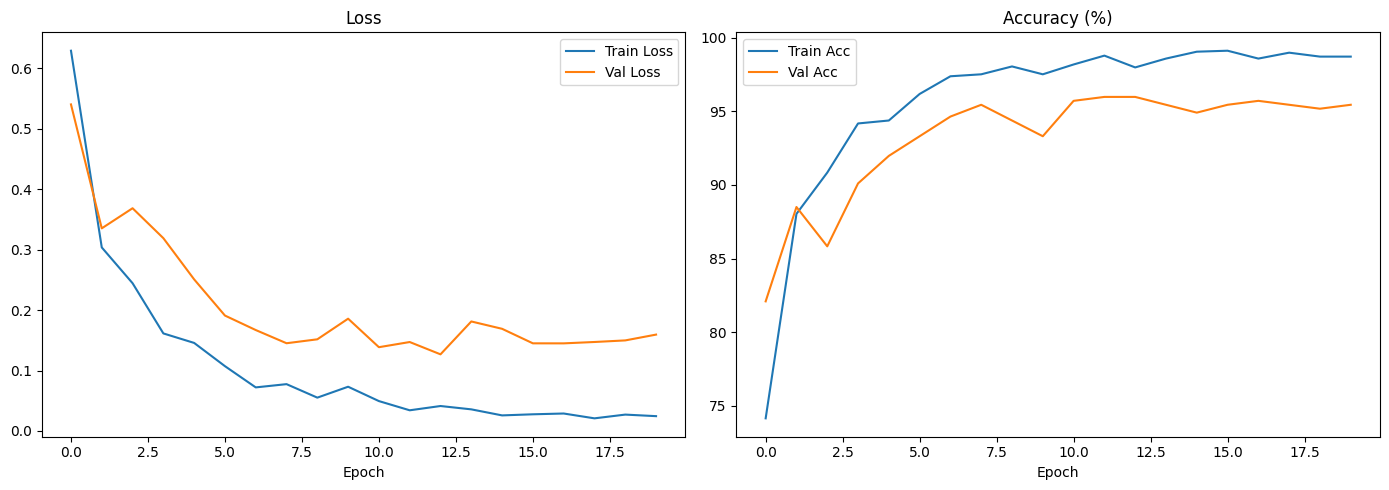

💾 Model saved to /content/makeup_classifier.pth


In [ ]:
import os, time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

# ─── CONFIG ───────────────────────────────────────────────
DATA_DIR = '/content/makeup_images_new'
CATEGORIES = ['no_makeup', 'clean_makeup', 'glam_makeup', 'festival_makeup']
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 0.001
VAL_SPLIT  = 0.2
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ──────────────────────────────────────────────────────────

print(f'🖥️  Using device: {DEVICE}')

# ─── TRANSFORMS ───────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ─── DATASET ──────────────────────────────────────────────
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transforms)
print(f'📁 Classes found: {full_dataset.classes}')
print(f'📊 Total images:  {len(full_dataset)}')

val_size   = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size
train_set, val_set = random_split(full_dataset, [train_size, val_size])
val_set.dataset = datasets.ImageFolder(DATA_DIR, transform=val_transforms)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f'🏋️  Train: {train_size} | 🧪 Val: {val_size}')

# ─── MODEL (ResNet18 pretrained) ──────────────────────────
model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4 + fc for better accuracy
for name, param in model.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True

# Replace final layer for 4 classes
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 4)
)
model = model.to(DEVICE)
print('✅ Model ready (ResNet18 — layer4 + fc unfrozen)')

# ─── TRAINING ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    start = time.time()
    model.train()
    train_loss, train_correct = 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * imgs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    scheduler.step()

    # Validation
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs   = model(imgs)
            loss      = criterion(outputs, labels)
            val_loss    += loss.item() * imgs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    t_loss = train_loss / train_size
    v_loss = val_loss   / val_size
    t_acc  = train_correct / train_size * 100
    v_acc  = val_correct   / val_size   * 100

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    print(f'Epoch {epoch+1:2d}/{EPOCHS} | '
          f'Train Loss: {t_loss:.3f} Acc: {t_acc:.1f}% | '
          f'Val Loss: {v_loss:.3f} Acc: {v_acc:.1f}% | '
          f'⏱ {time.time()-start:.1f}s')

print('\n🎉 Training complete!')

# ─── PLOT ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'],   label='Val Loss')
ax1.set_title('Loss'); ax1.legend(); ax1.set_xlabel('Epoch')

ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['val_acc'],   label='Val Acc')
ax2.set_title('Accuracy (%)'); ax2.legend(); ax2.set_xlabel('Epoch')

plt.tight_layout()
plt.show()

# ─── SAVE MODEL ───────────────────────────────────────────
torch.save({
    'model_state_dict': model.state_dict(),
    'classes': full_dataset.classes,
    'img_size': IMG_SIZE,
}, '/content/makeup_classifier.pth')
print('💾 Model saved to /content/makeup_classifier.pth')

In [ ]:
from google.colab import files
files.download('/content/makeup_classifier.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>